In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# EDA

In [2]:
df = pd.read_csv("19-heart.csv")
print("Shape: ", df.shape)
print("Columns: ", df.columns)
print("İnformations: ")
df.info()
print("İsnull Values: \n", df.isnull().sum())
display(df.head())
display(df.describe())

Shape:  (303, 14)
Columns:  Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
İnformations: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
İsnull Values: 
 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [3]:
cols1 = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cols2 = [i for i in df.columns if i not in cols1]
print(cols1)
print(cols2)

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


In [4]:
def see_numerical(data, columns):
    
    fig, ax = plt.subplots(2,3,figsize=(20,10))
    ax = ax.flatten()
    for i, col in enumerate(columns):
        sns.kdeplot(
            x = col,
            data = data,
            ax = ax[i]
        )
        ax[i].set_title(f"{col} kdeplot")

    for i in range(i+1, len(ax)):
        ax[i].axis("off")
        
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(2,3,figsize=(20,10))
    ax2 = ax2.flatten()
    for j, col1 in enumerate(columns):
        sns.boxplot(
            y = col1,
            data = data,
            ax = ax2[j]
        )
        ax2[j].set_title(f"{col1} boxplot")
    
    for j in range(j+1, len(ax2)):
        ax2[j].axis("off")
    
    plt.tight_layout()
    plt.show()

def see_categorics(data, columns):
    
    fig, ax = plt.subplots(3,3,figsize=(20,10)) 
    ax = ax.flatten()
    for i, col in enumerate(columns):
        sns.countplot(
            x = col,
            data = data,
            ax = ax[i]
        )
        ax[i].set_title(f"{col} countplot")
    plt.tight_layout()
    plt.show()

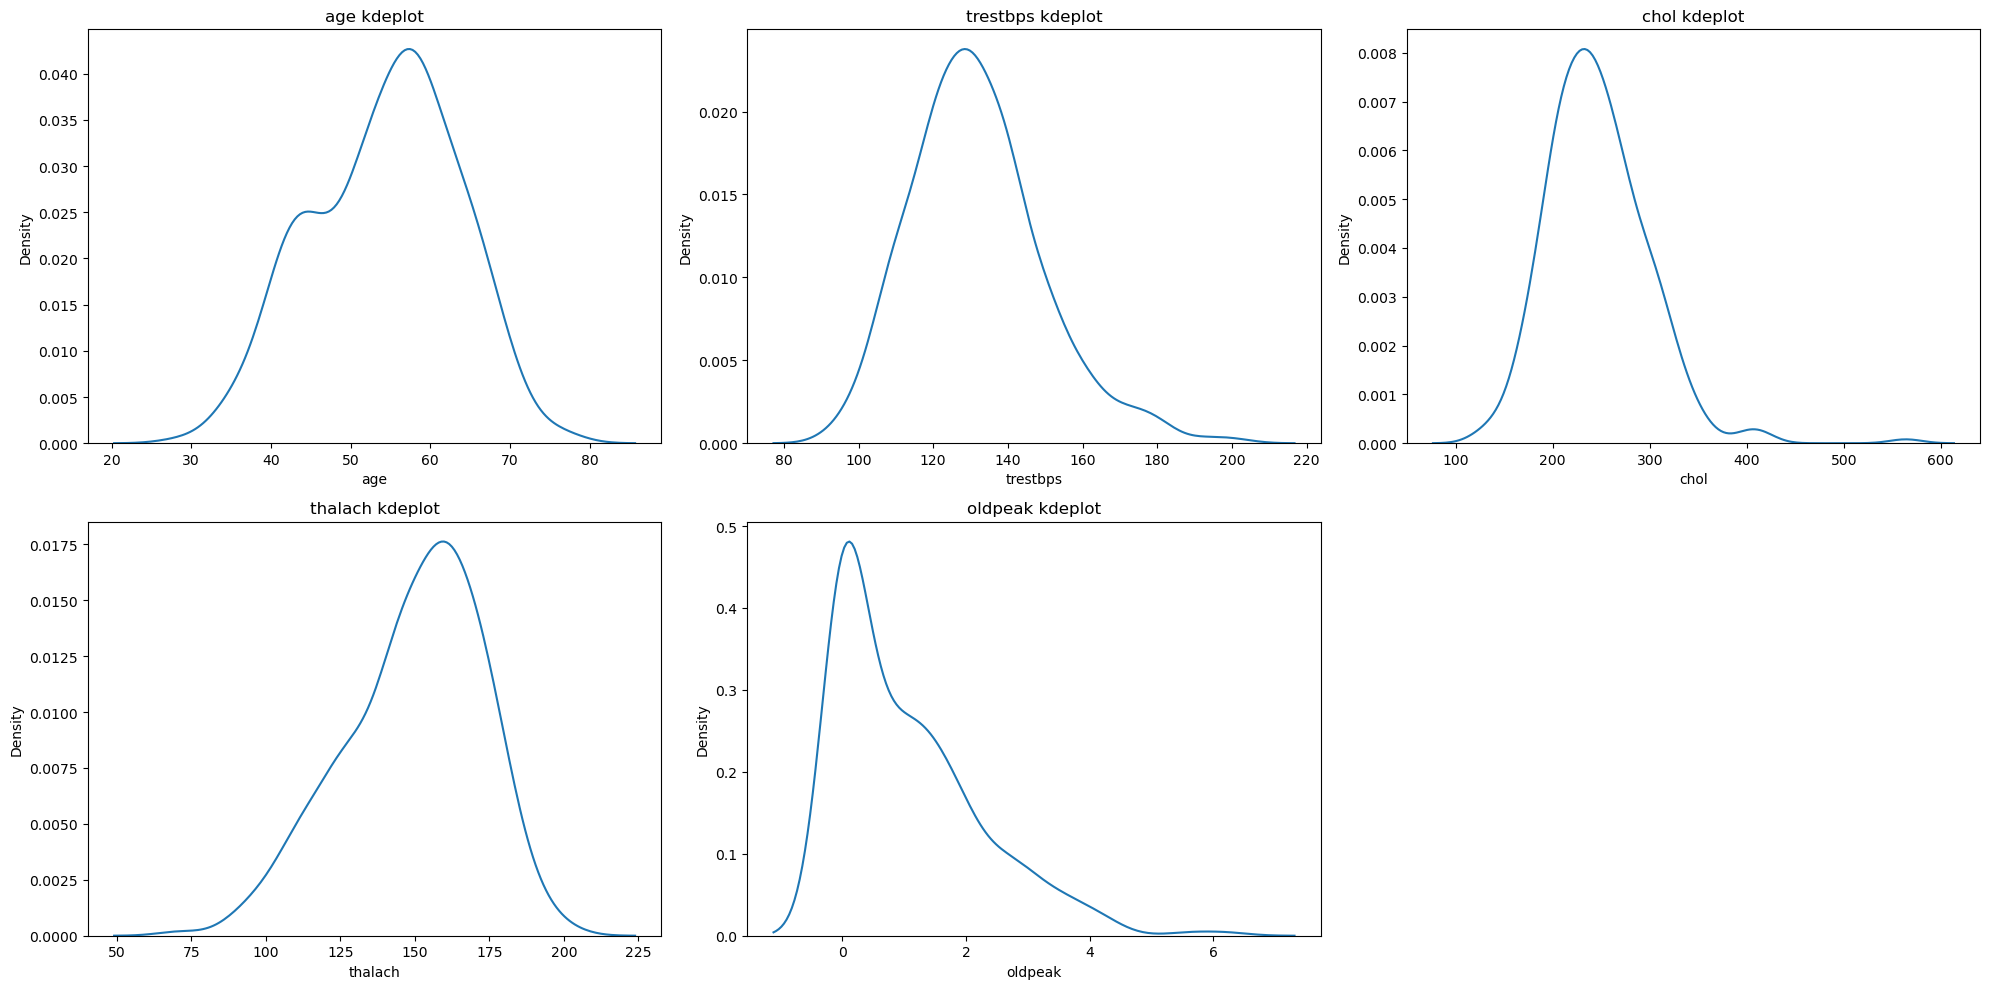

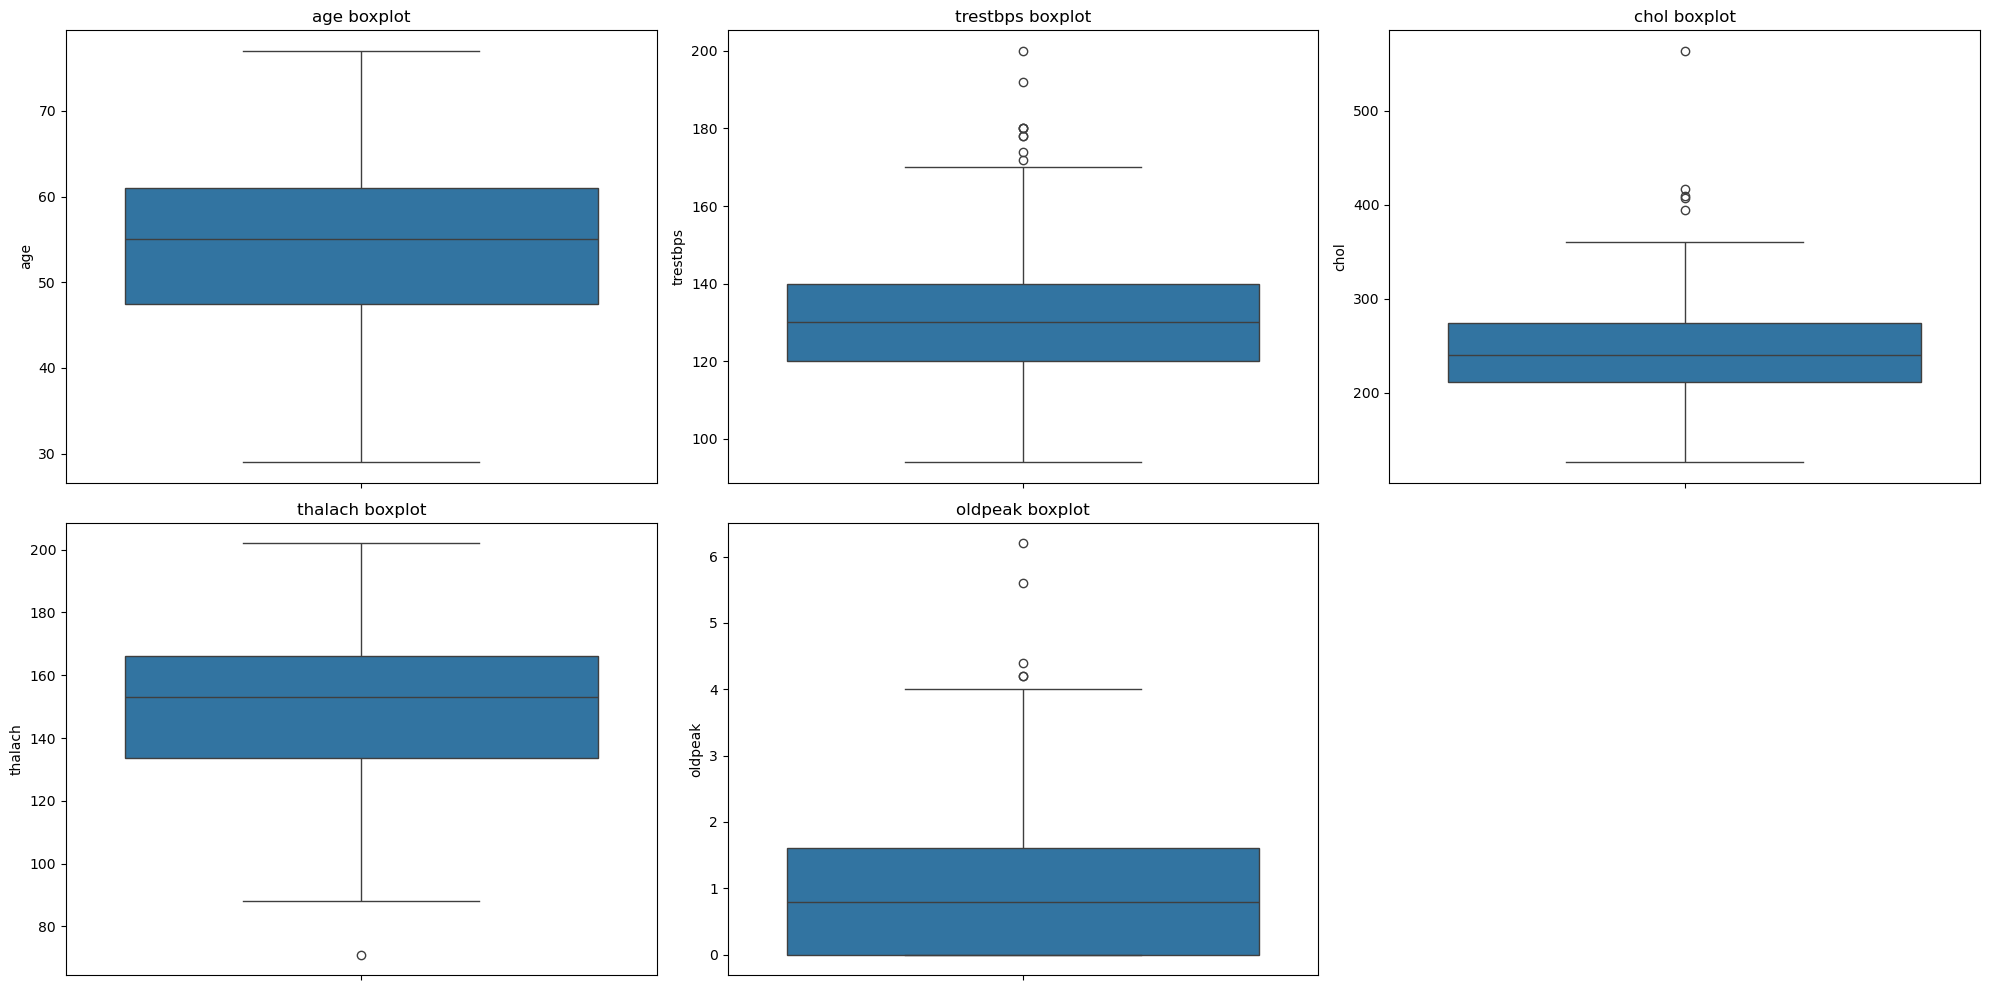

In [5]:
see_numerical(df, cols1)

In [6]:
df = df[df["chol"] < 500]

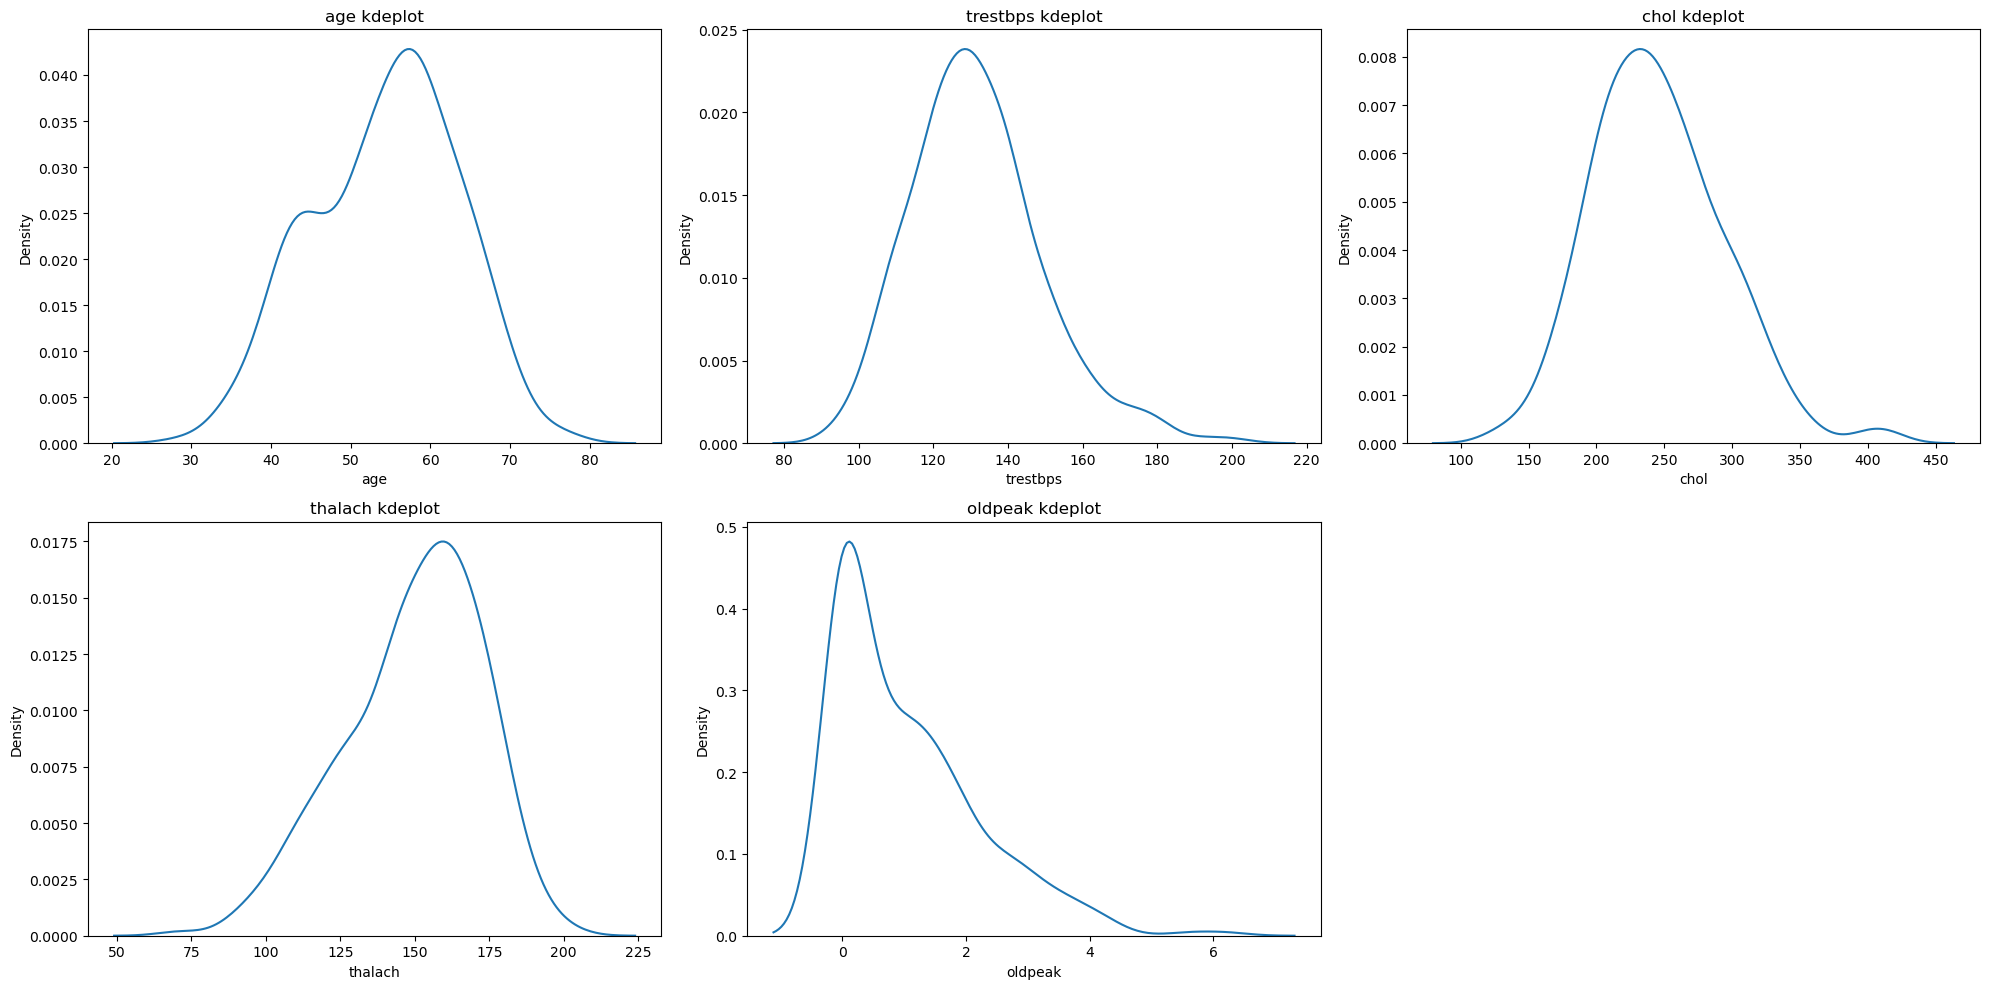

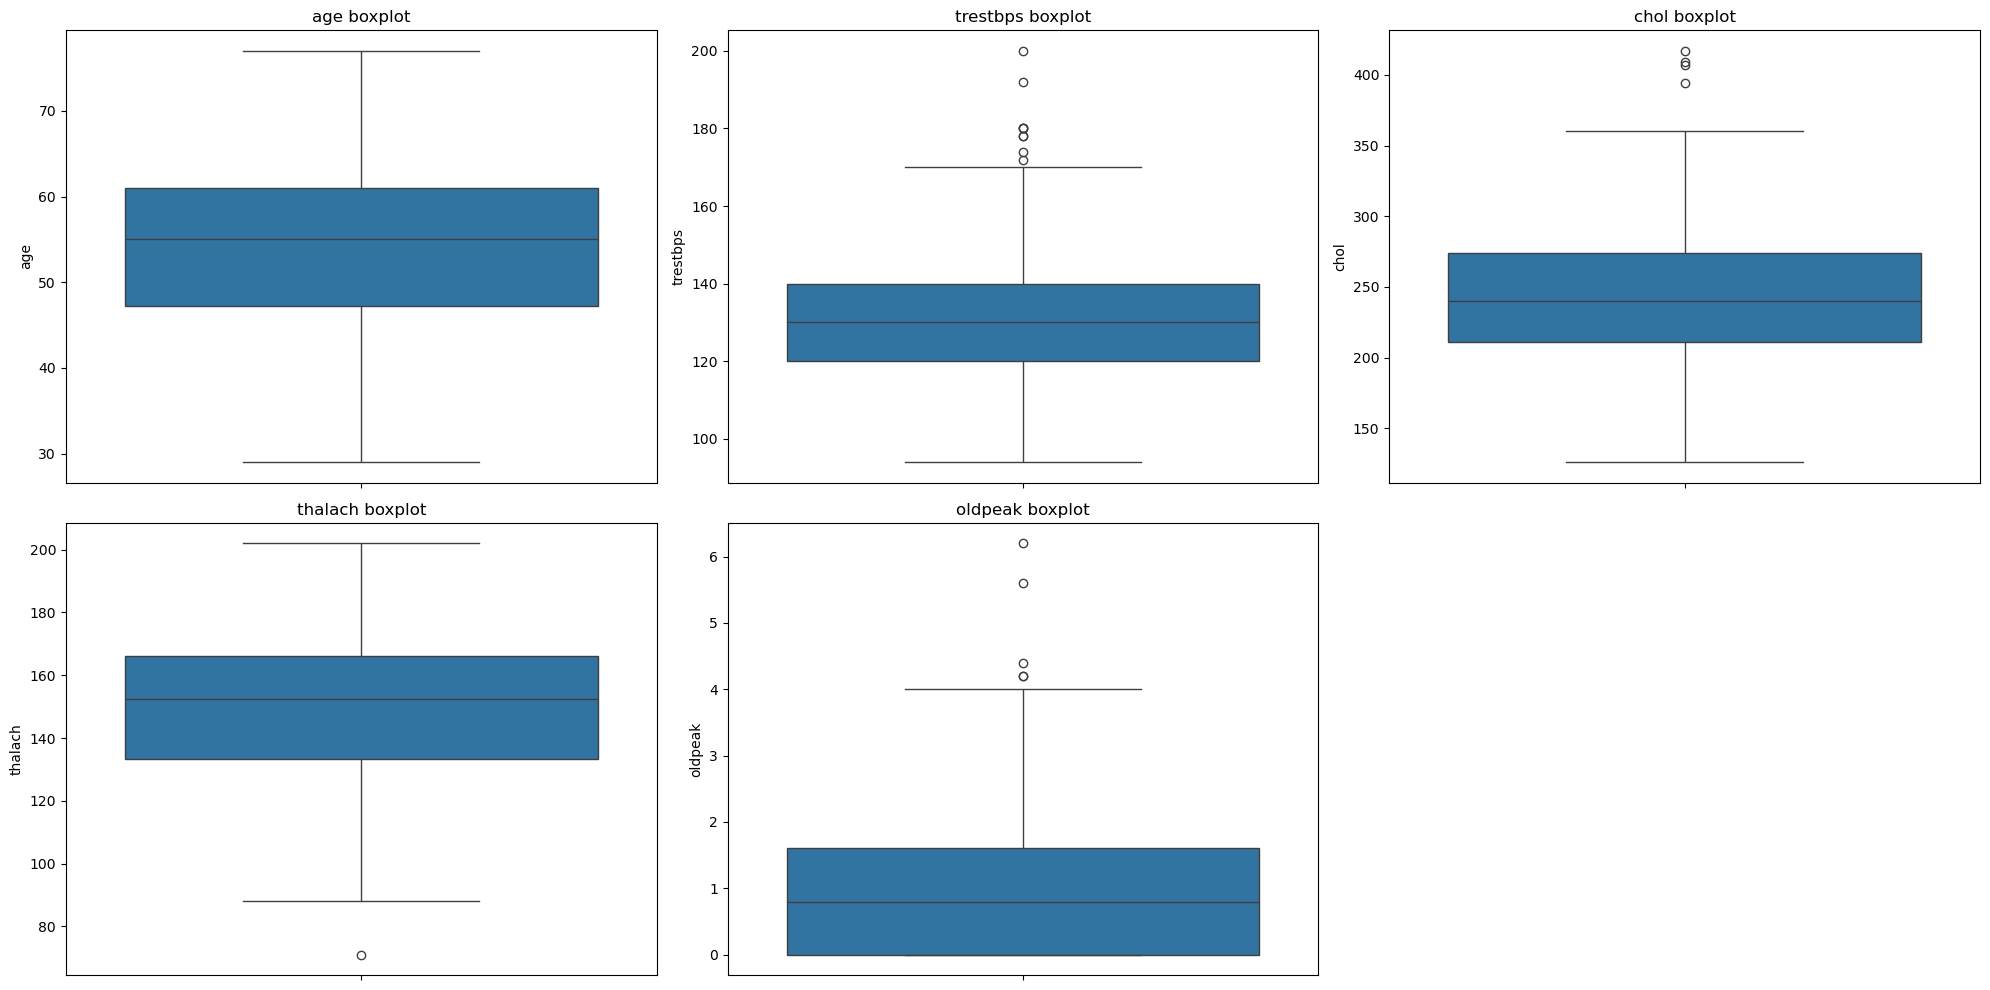

In [7]:
see_numerical(df, cols1)

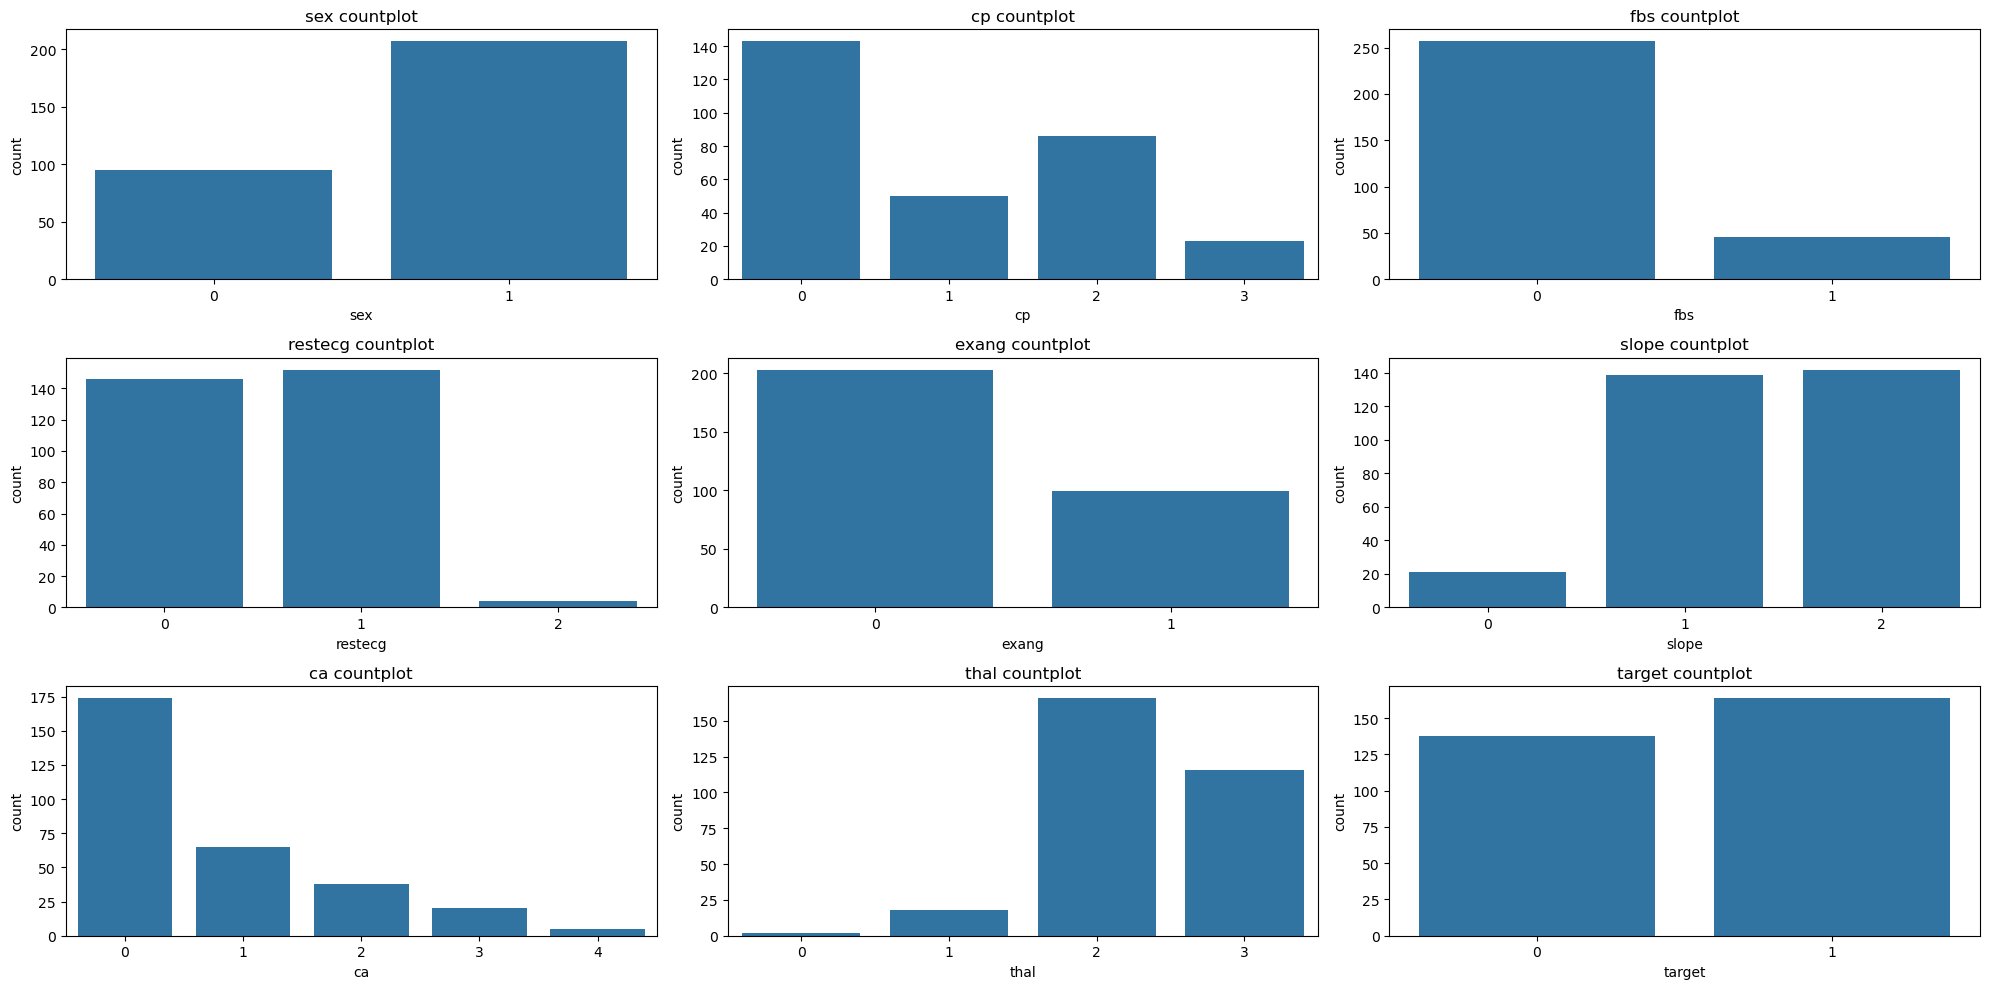

In [8]:
see_categorics(df, cols2)

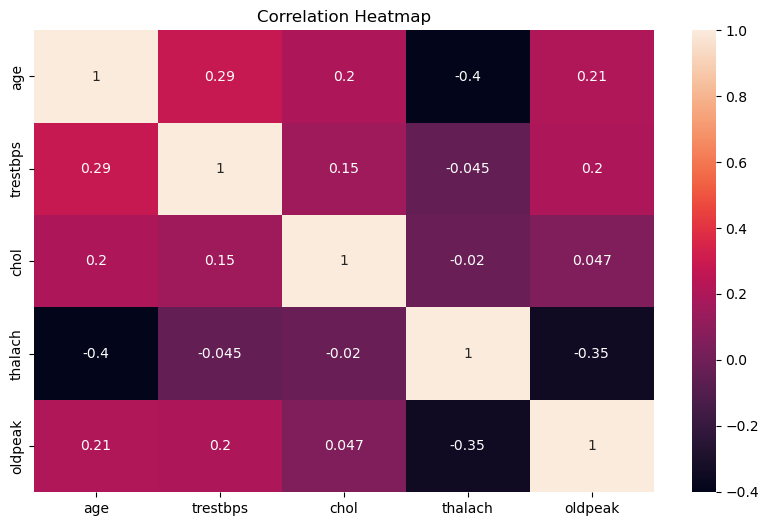

In [9]:
plt.figure(figsize=(10,6))
corr = df[cols1].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

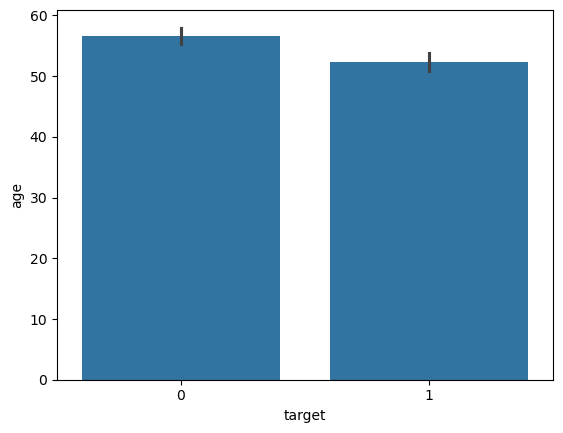

In [10]:
sns.barplot(x="target", y="age", data=df)
plt.show()

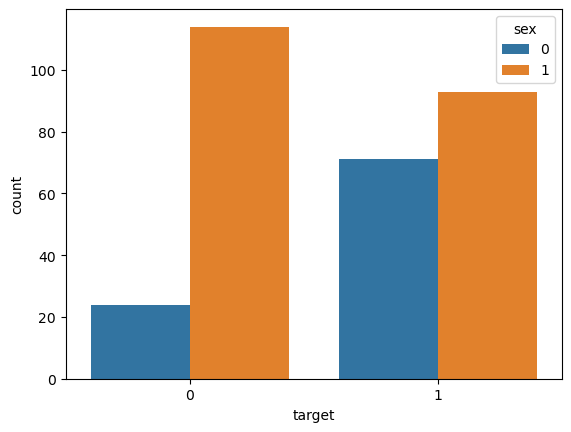

In [11]:
sns.countplot(x="target", hue="sex", data=df)
plt.show()

In [12]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# Model Building

In [13]:
from sklearn.model_selection import train_test_split
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score ,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

def train_and_evaluate(models, X_train, X_test, y_train, y_test):

    def calculate(true, prediction):
        accuracy = accuracy_score(true, prediction)
        precision = precision_score(true, prediction, zero_division=0)
        recall = recall_score(true, prediction, zero_division=0)
        f1 = f1_score(true, prediction, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(true, prediction).ravel()
        return (accuracy, precision, recall, f1, tn, fp, fn ,tp)
    
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        train_acc, train_prec, train_rec, train_f1, train_tp, train_fp, train_fn, train_tn = calculate(y_train, y_train_pred)
        test_acc, test_prec, test_rec, test_f1, test_tp, test_fp, test_fn, test_tn = calculate(y_test, y_test_pred)
        overfit_gap = train_acc - test_acc
        result = {
            "name": name,
            "train_acc": train_acc,
            "train_prec": train_prec,
            "train_rec": train_rec,
            "train_f1": train_f1,
            "train_tn": train_tn,
            "train_fp": train_fp,
            "train_fn": train_fn,
            "train_tp": train_tp,
            "test_acc": test_acc,
            "test_prec": test_prec,
            "test_rec": test_rec,
            "test_f1": test_f1,
            "test_tn": test_tn,
            "test_fp": test_fp,
            "test_fn": test_fn,
            "test_tp": test_tp,
            "overfit_gap": overfit_gap
        }
        results.append(result)
    results = pd.DataFrame(results)
    results = results.sort_values("test_acc", ascending=False)
    return results

In [16]:
models = {
    "logistic_regression": LogisticRegression(),
    "svc": SVC(),
    "GaussianNB": GaussianNB(),
    "knn_classifier": KNeighborsClassifier(),
    "decision_tree_classifier": DecisionTreeClassifier(),
    "random_forest_classifier": RandomForestClassifier(),
    "adaboost_classifier": AdaBoostClassifier(),
    "gradient_boosting_classifier": GradientBoostingClassifier()
}
result1 = train_and_evaluate(models, X_train_scaled, X_test_scaled, y_train, y_test)

In [17]:
result1

,name,train_acc,train_prec,train_rec,train_f1,train_tn,train_fp,train_fn,train_tp,test_acc,test_prec,test_rec,test_f1,test_tn,test_fp,test_fn,test_tp,overfit_gap
3,knn_classifier,0.867220,0.848921,0.914729,0.880597,118,21,11,91,0.819672,0.833333,0.857143,0.845070,30,6,5,20,0.047548
5,random_forest_classifier,1.000000,1.000000,1.000000,1.000000,129,0,0,112,0.803279,0.794872,0.885714,0.837838,31,8,4,18,0.196721
0,logistic_regression,0.871369,0.845070,0.930233,0.885609,120,22,9,90,0.786885,0.761905,0.914286,0.831169,32,10,3,16,0.084484
1,svc,0.908714,0.896296,0.937984,0.916667,121,14,8,98,0.786885,0.789474,0.857143,0.821918,30,8,5,18,0.121828
6,adaboost_classifier,0.912863,0.921875,0.914729,0.918288,118,10,11,102,0.786885,0.775000,0.885714,0.826667,31,9,4,17,0.125978
7,gradient_boosting_classifier,0.995851,0.992308,1.000000,0.996139,129,1,0,111,0.754098,0.763158,0.828571,0.794521,29,9,6,17,0.241752
2,GaussianNB,0.858921,0.841727,0.906977,0.873134,117,22,12,90,0.737705,0.756757,0.800000,0.777778,28,9,7,17,0.121216
4,decision_tree_classifier,1.000000,1.000000,1.000000,1.000000,129,0,0,112,0.737705,0.756757,0.800000,0.777778,28,9,7,17,0.262295


In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
    
def tuning(X_train, y_train):
    cv = StratifiedKFold(n_splits=5)
    rf_params = {
        "n_estimators": [100,150,200,300],
        "max_depth": [3,4,5,7,10,None],
        "min_samples_split": [2,3,5,10],
        "min_samples_leaf": [2,3,5,10]
    }
    ab_params = {
        "n_estimators": [100,150,200,250],
        "learning_rate": [0.01, 0.05, 0.1, 0.2]
    }
    gb_params = {
        "n_estimators": [100,150,200,250],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth": [3,4,5,6,7]
    }
    models = [
        ("RFC", RandomForestClassifier(), rf_params),
        ("ABC", AdaBoostClassifier(), ab_params),
        ("GBC", GradientBoostingClassifier(), gb_params)
    ]
    params = []
    for name, model, param in models:
        grid = GridSearchCV(estimator=model, param_grid=param, cv=cv, n_jobs=-1, scoring="accuracy")
        grid.fit(X_train, y_train)
        result = (name, grid.best_params_)
        params.append(result)
    return params

params = tuning(X_train_scaled, y_train)

In [27]:
params

[('RFC',
  {'max_depth': 7,
   'min_samples_leaf': 5,
   'min_samples_split': 10,
   'n_estimators': 100}),
 ('ABC', {'learning_rate': 0.05, 'n_estimators': 100}),
 ('GBC', {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100})]

In [53]:
tuning_models = {
    "random_forest_classifier": RandomForestClassifier(random_state=42, max_depth=5 ,min_samples_leaf=5, min_samples_split=5),
    "adabost_classifier": AdaBoostClassifier(random_state=42, learning_rate=0.1, n_estimators=400),
    "gradient_boosting_classifier": GradientBoostingClassifier(random_state=42, learning_rate=0.1, n_estimators=200, max_depth=5)
}
tuning_result = train_and_evaluate(tuning_models, X_train_scaled, X_test_scaled, y_train, y_test)

In [54]:
tuning_result

,name,train_acc,train_prec,train_rec,train_f1,train_tn,train_fp,train_fn,train_tp,test_acc,test_prec,test_rec,test_f1,test_tn,test_fp,test_fn,test_tp,overfit_gap
1,adabost_classifier,0.887967,0.880597,0.914729,0.897338,118,16,11,96,0.836066,0.837838,0.885714,0.861111,31,6,4,20,0.051901
2,gradient_boosting_classifier,1.000000,1.000000,1.000000,1.000000,129,0,0,112,0.803279,0.810811,0.857143,0.833333,30,7,5,19,0.196721
0,random_forest_classifier,0.912863,0.897059,0.945736,0.920755,122,14,7,98,0.770492,0.783784,0.828571,0.805556,29,8,6,18,0.142371


In [55]:
result1

,name,train_acc,train_prec,train_rec,train_f1,train_tn,train_fp,train_fn,train_tp,test_acc,test_prec,test_rec,test_f1,test_tn,test_fp,test_fn,test_tp,overfit_gap
3,knn_classifier,0.867220,0.848921,0.914729,0.880597,118,21,11,91,0.819672,0.833333,0.857143,0.845070,30,6,5,20,0.047548
5,random_forest_classifier,1.000000,1.000000,1.000000,1.000000,129,0,0,112,0.803279,0.794872,0.885714,0.837838,31,8,4,18,0.196721
0,logistic_regression,0.871369,0.845070,0.930233,0.885609,120,22,9,90,0.786885,0.761905,0.914286,0.831169,32,10,3,16,0.084484
1,svc,0.908714,0.896296,0.937984,0.916667,121,14,8,98,0.786885,0.789474,0.857143,0.821918,30,8,5,18,0.121828
6,adaboost_classifier,0.912863,0.921875,0.914729,0.918288,118,10,11,102,0.786885,0.775000,0.885714,0.826667,31,9,4,17,0.125978
7,gradient_boosting_classifier,0.995851,0.992308,1.000000,0.996139,129,1,0,111,0.754098,0.763158,0.828571,0.794521,29,9,6,17,0.241752
2,GaussianNB,0.858921,0.841727,0.906977,0.873134,117,22,12,90,0.737705,0.756757,0.800000,0.777778,28,9,7,17,0.121216
4,decision_tree_classifier,1.000000,1.000000,1.000000,1.000000,129,0,0,112,0.737705,0.756757,0.800000,0.777778,28,9,7,17,0.262295
